In [1]:
# Core libraries for data manipulation and numerical operations
import numpy as np
import pandas as pd

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, model selection, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve)

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# TensorFlow/Keras for neural network implementation
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Reproducibility: Setting random seeds for consistent results
import os
import random

#Set Python's built-in random seed
SEED = 123
random.seed(SEED)
#Set PYTHONHASHSEED environment variable
os.environ['PYTHONHASHSEED'] = str(SEED)
#Set NumPy random seed
np.random.seed(SEED)

#Set TensorFlow random seed
tf.random.set_seed(SEED)

#Enable TensorFlow deterministic operations
#This forces TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()


In [2]:
# Load the cervical cancer risk factors dataset.
# The raw data is not tracked in Git - run `python src/download_data.py`
# from the project root first (see README > Data Sources).
from pathlib import Path

DATA_PATH = Path('..') / 'data' / 'raw' / 'kag_risk_factors_cervical_cancer.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. From the project root, run:\n"
        "    python src/download_data.py")

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape[0]} samples, {df.shape[1]} features")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Dataset Shape: 858 samples, 36 features

Column Names:
   1. Age
   2. Number of sexual partners
   3. First sexual intercourse
   4. Num of pregnancies
   5. Smokes
   6. Smokes (years)
   7. Smokes (packs/year)
   8. Hormonal Contraceptives
   9. Hormonal Contraceptives (years)
  10. IUD
  11. IUD (years)
  12. STDs
  13. STDs (number)
  14. STDs:condylomatosis
  15. STDs:cervical condylomatosis
  16. STDs:vaginal condylomatosis
  17. STDs:vulvo-perineal condylomatosis
  18. STDs:syphilis
  19. STDs:pelvic inflammatory disease
  20. STDs:genital herpes
  21. STDs:molluscum contagiosum
  22. STDs:AIDS
  23. STDs:HIV
  24. STDs:Hepatitis B
  25. STDs:HPV
  26. STDs: Number of diagnosis
  27. STDs: Time since first diagnosis
  28. STDs: Time since last diagnosis
  29. Dx:Cancer
  30. Dx:CIN
  31. Dx:HPV
  32. Dx
  33. Hinselmann
  34. Schiller
  35. Citology
  36. Biopsy


In [3]:
# Examine first few records to understand data structure
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [4]:
# Check data types - note that '?' placeholders cause columns to be read as 'object' type
print("Data Types Summary:")
print(df.dtypes.value_counts())
print("\nColumns with 'object' dtype (likely contain '?' missing values):")
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(object_cols)

Data Types Summary:
object    26
int64     10
Name: count, dtype: int64

Columns with 'object' dtype (likely contain '?' missing values):
['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


In [5]:
# Quantify '?' missing value placeholders across all columns
missing_counts = {}
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        missing_counts[col] = count

# Create DataFrame for visualization
missing_df = pd.DataFrame({
    'Column': list(missing_counts.keys()),
    'Missing Count': list(missing_counts.values()),
    'Missing %': [count/len(df)*100 for count in missing_counts.values()]}).sort_values('Missing Count', ascending=False)

print(f"Total columns with missing values: {len(missing_counts)}")
print(f"Total '?' occurrences: {sum(missing_counts.values())}\n")
print(missing_df.to_string(index=False))

Total columns with missing values: 26
Total '?' occurrences: 3622

                            Column  Missing Count  Missing %
  STDs: Time since first diagnosis            787  91.724942
   STDs: Time since last diagnosis            787  91.724942
                       IUD (years)            117  13.636364
                               IUD            117  13.636364
           Hormonal Contraceptives            108  12.587413
   Hormonal Contraceptives (years)            108  12.587413
                     STDs (number)            105  12.237762
                              STDs            105  12.237762
STDs:vulvo-perineal condylomatosis            105  12.237762
       STDs:vaginal condylomatosis            105  12.237762
  STDs:pelvic inflammatory disease            105  12.237762
                     STDs:syphilis            105  12.237762
               STDs:genital herpes            105  12.237762
        STDs:molluscum contagiosum            105  12.237762
                  

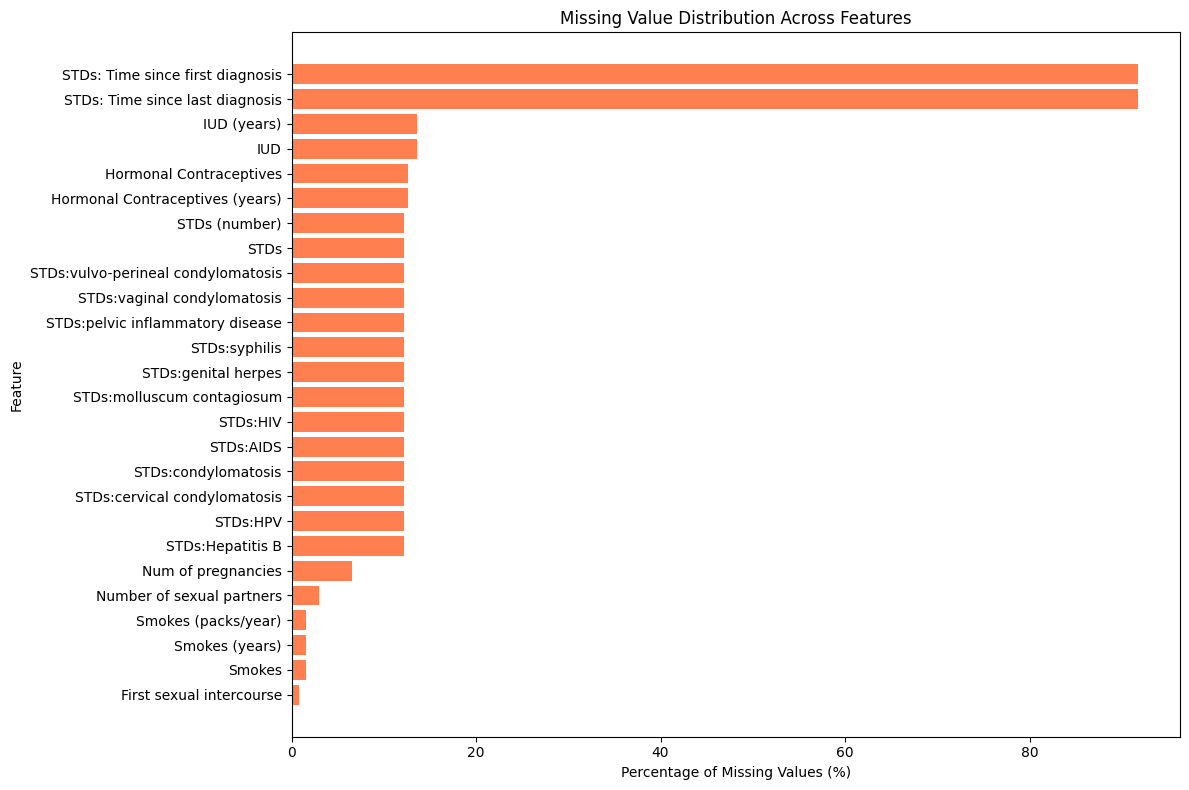

In [6]:
# Visualize missing value distribution
plt.figure(figsize=(12, 8))
plt.barh(missing_df['Column'], missing_df['Missing %'], color='coral')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Feature')
plt.title('Missing Value Distribution Across Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Target Variable Distribution:
  Negative (0): 803 samples (93.59%)
  Positive (1): 55 samples (6.41%)

Imbalance Ratio: 14.6:1


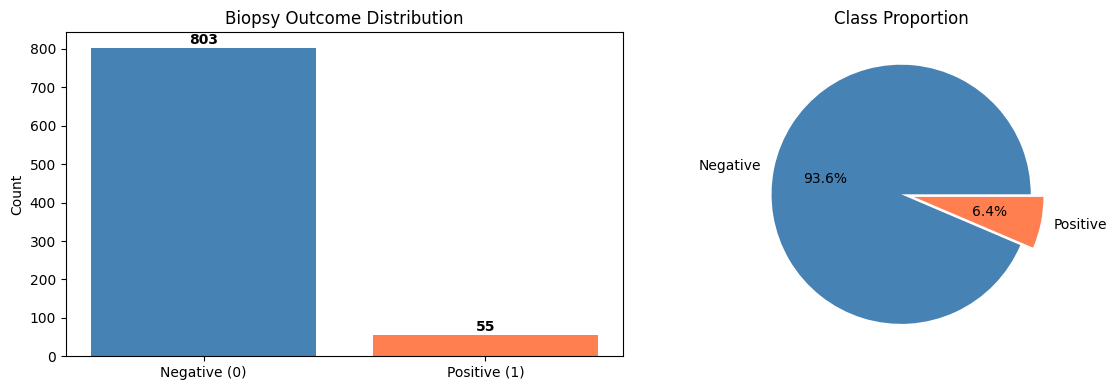

In [7]:
# Analyze target variable distribution
target_counts = df['Biopsy'].value_counts()
target_percentages = df['Biopsy'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"  Negative (0): {target_counts[0]} samples ({target_percentages[0]:.2f}%)")
print(f"  Positive (1): {target_counts[1]} samples ({target_percentages[1]:.2f}%)")
print(f"\nImbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Negative (0)', 'Positive (1)'], target_counts.values, color=['steelblue', 'coral'])
axes[0].set_ylabel('Count')
axes[0].set_title('Biopsy Outcome Distribution')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Negative', 'Positive'], autopct='%1.1f%%',
            colors=['steelblue', 'coral'], explode=[0, 0.1])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

In [8]:
# Convert '?' placeholders to NaN for proper handling
df_clean = df.replace('?', np.nan)

# Convert all columns to numeric type
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Data types after conversion:")
print(df_clean.dtypes.value_counts())
print(f"\nTotal NaN values: {df_clean.isna().sum().sum()}")

Data types after conversion:
float64    26
int64      10
Name: count, dtype: int64

Total NaN values: 3622


In [9]:
# Remove columns with excessive missing values (>80%)
# STDs diagnosis time columns have ~92% missing data and provide limited predictive value
cols_to_drop = ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Removed {len(cols_to_drop)} columns with >80% missing values")
print(f"Remaining features: {df_clean.shape[1]}")

Removed 2 columns with >80% missing values
Remaining features: 34


In [10]:
# Separate features and target
X = df_clean.drop(columns=['Biopsy'])
y = df_clean['Biopsy']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (858, 33)
Target shape: (858,)


In [11]:
# Identify continuous and categorical/binary columns for appropriate imputation
# Continuous: Age, years, counts | Binary: Smokes, STDs flags, etc.

continuous_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse',
                   'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)',
                   'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)',
                   'STDs: Number of diagnosis']

binary_cols = [col for col in X.columns if col not in continuous_cols]

print(f"Continuous columns: {len(continuous_cols)}")
print(f"Binary/Categorical columns: {len(binary_cols)}")

Continuous columns: 10
Binary/Categorical columns: 23


In [12]:
# Imputation strategy:
# - Continuous variables: Median imputation
# - Binary variables: Mode imputation

# Impute continuous columns with median
median_imputer = SimpleImputer(strategy='median')
X[continuous_cols] = median_imputer.fit_transform(X[continuous_cols])

# Impute binary columns with mode (most frequent)
mode_imputer = SimpleImputer(strategy='most_frequent')
X[binary_cols] = mode_imputer.fit_transform(X[binary_cols])

print(f"Remaining NaN values after imputation: {X.isna().sum().sum()}")

Remaining NaN values after imputation: 0


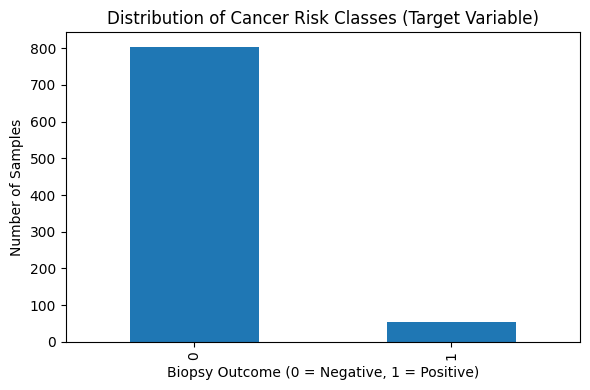

In [13]:
# Target Variable Distribution (Class Balance)

plt.figure(figsize=(6, 4))
df_clean['Biopsy'].value_counts().plot(kind='bar')

plt.title("Distribution of Cancer Risk Classes (Target Variable)")
plt.xlabel("Biopsy Outcome (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()


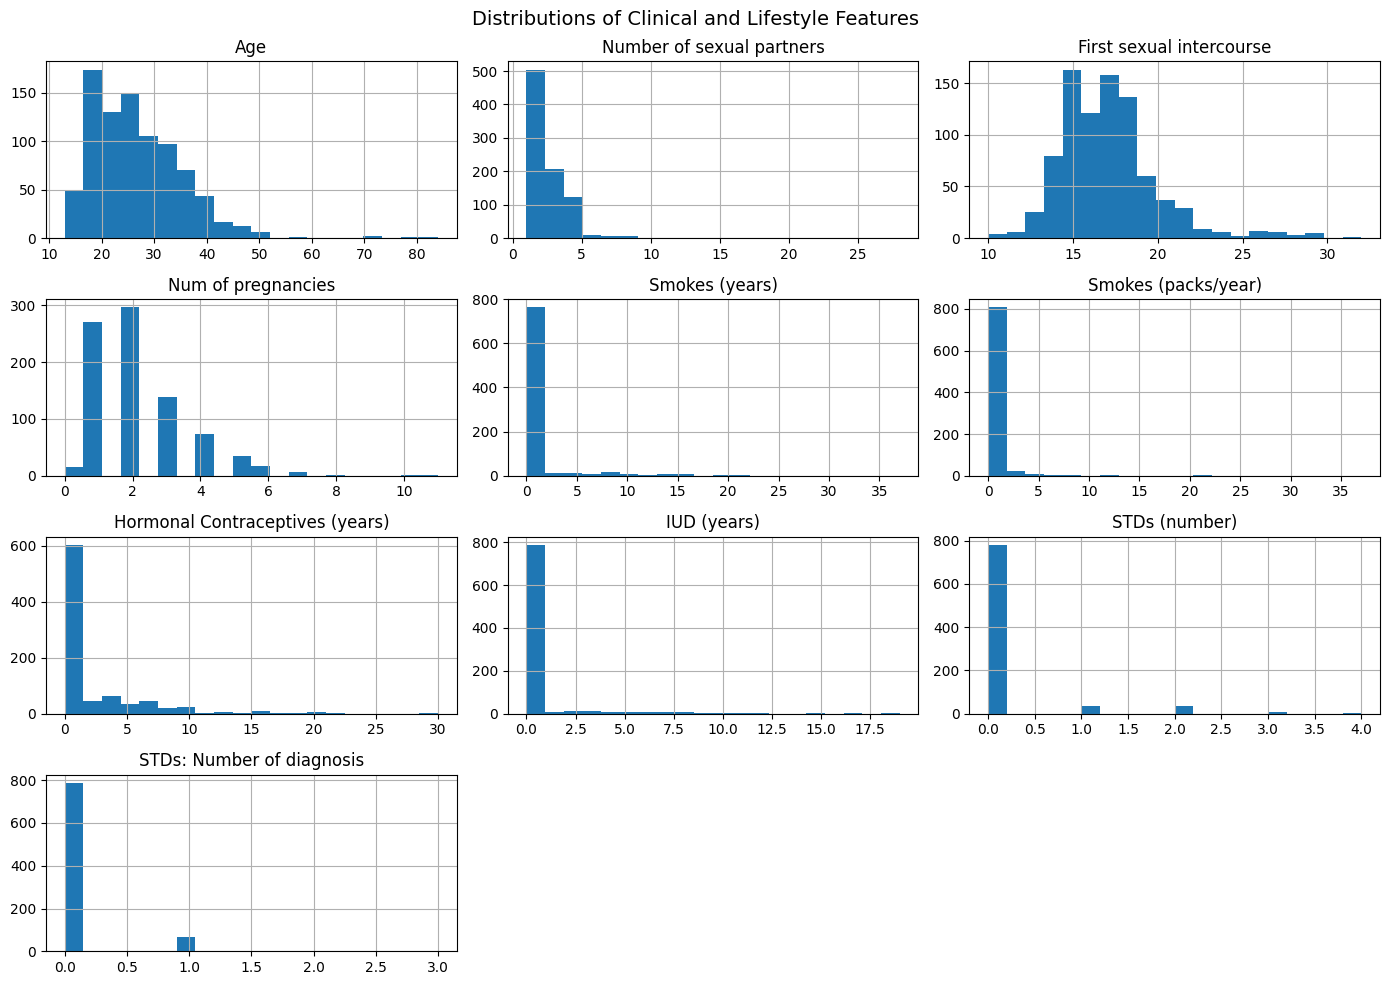

In [14]:
# Feature Distributions (Univariate Analysis)


# Convert continuous columns into a clean DataFrame for plotting
X_cont = pd.DataFrame(X[continuous_cols], columns=continuous_cols)

# Plot histograms for all continuous variables
X_cont.hist(figsize=(14, 10), bins=20)

plt.suptitle("Distributions of Clinical and Lifestyle Features", fontsize=14)
plt.tight_layout()
plt.show()


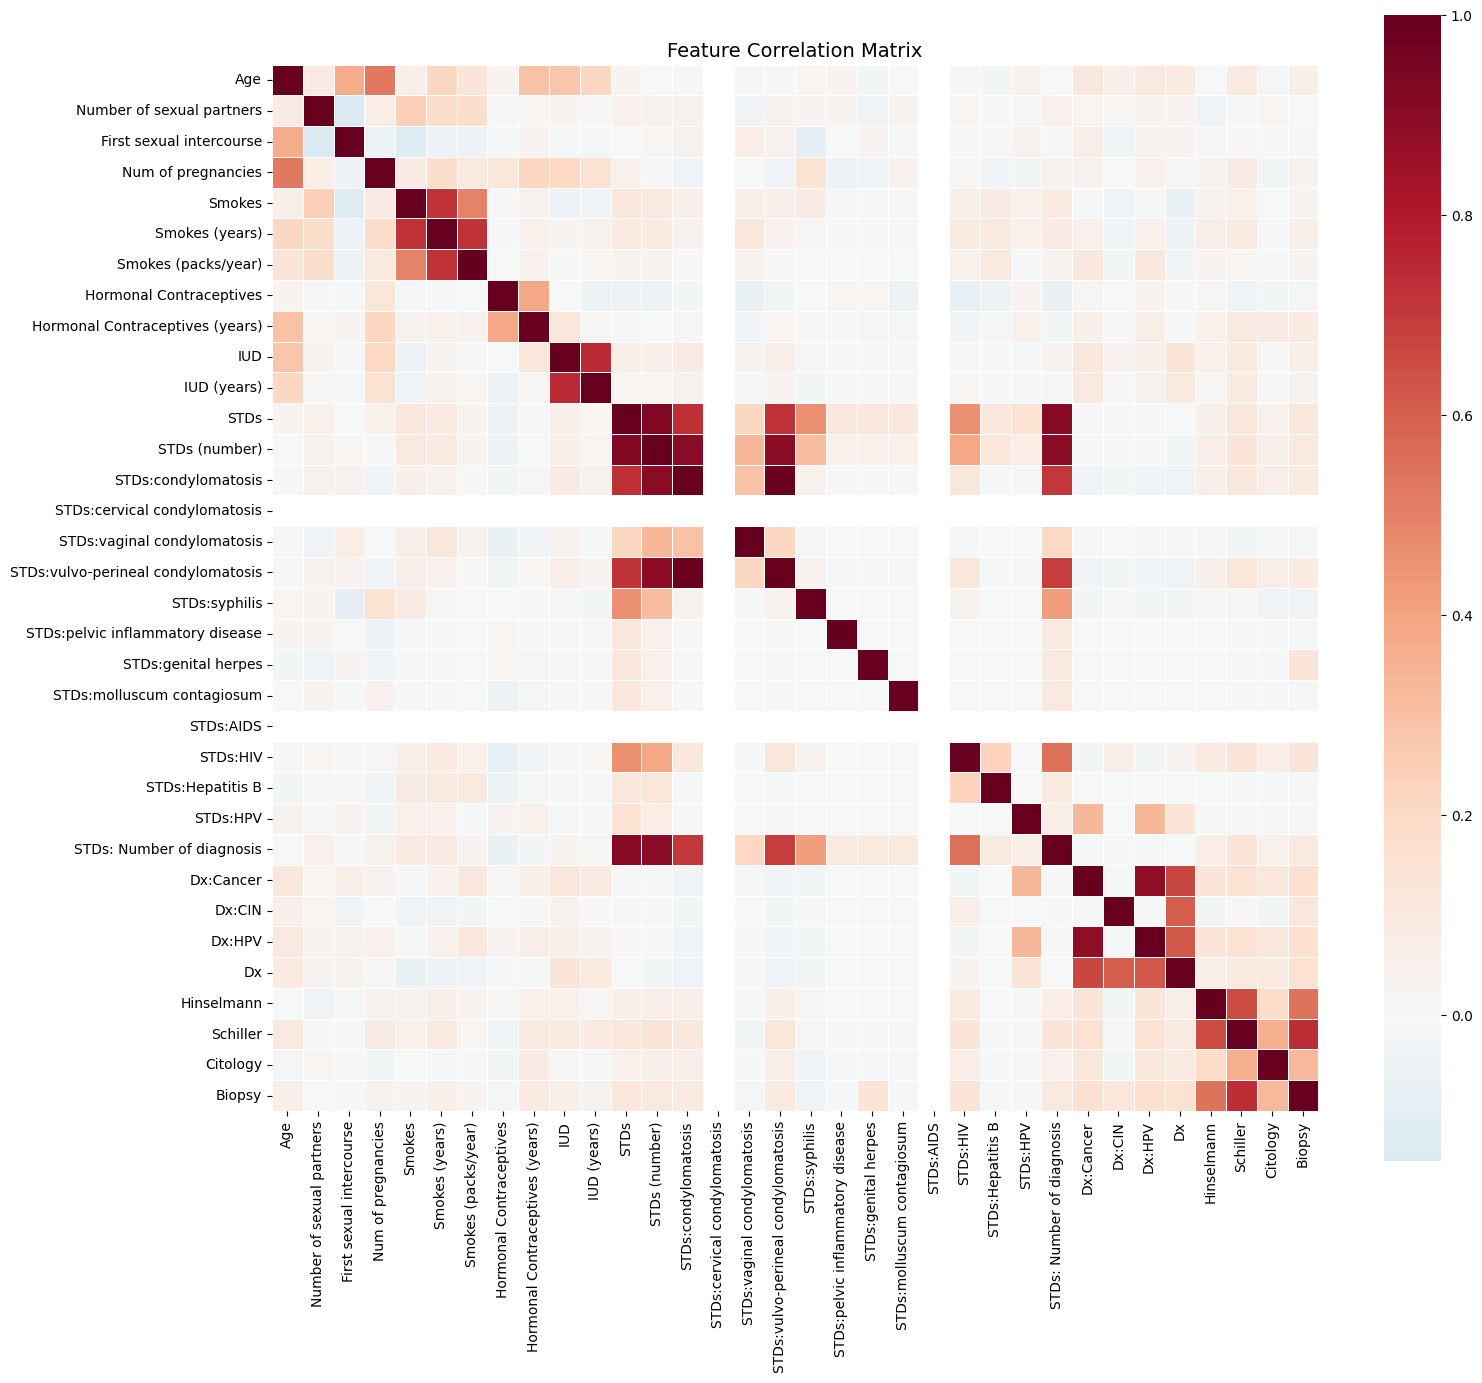

In [15]:
# Compute correlation matrix including target variable
corr_data = X.copy()
corr_data['Biopsy'] = y.values
corr_matrix = corr_data.corr()

# Visualize correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Identify features most correlated with Biopsy outcome
target_correlations = corr_matrix['Biopsy'].drop('Biopsy').abs().sort_values(ascending=False)
print("Top 10 Features Correlated with Biopsy Outcome:")
print(target_correlations.head(10).to_string())

Top 10 Features Correlated with Biopsy Outcome:
Schiller               0.733204
Hinselmann             0.547417
Citology               0.327466
Dx:Cancer              0.160905
Dx:HPV                 0.160905
Dx                     0.157607
STDs:genital herpes    0.130523
STDs:HIV               0.127702
STDs                   0.114148
Dx:CIN                 0.113172


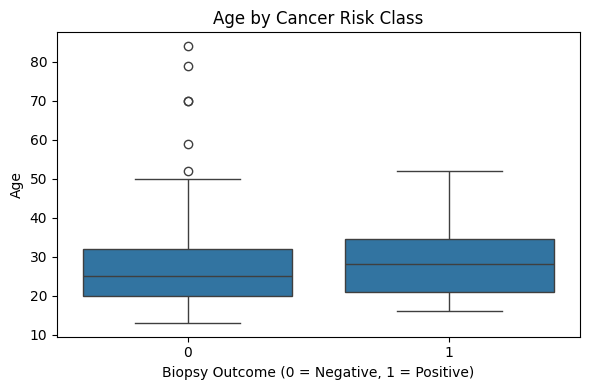

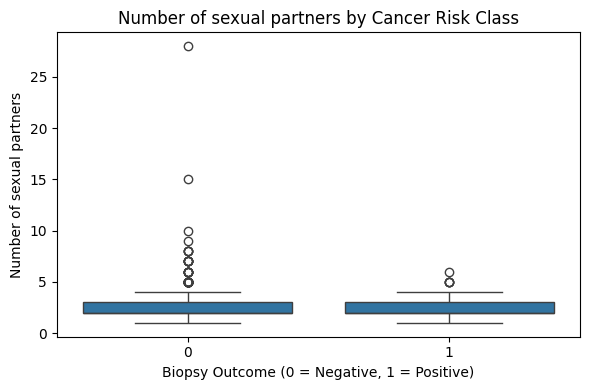

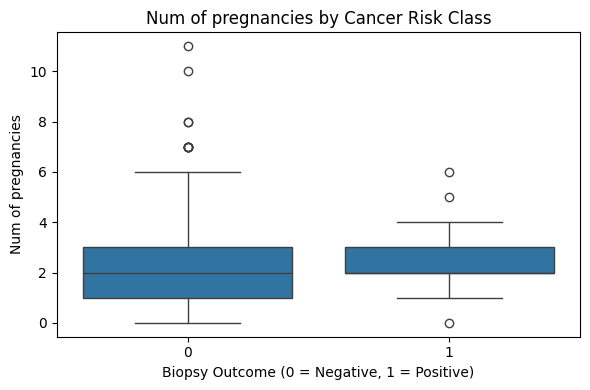

In [17]:
# Feature Distributions by Cancer Risk Class


# Choose a small set of informative continuous variables for class comparison
eda_features = ['Age', 'Number of sexual partners', 'Num of pregnancies']

# Create a combined DataFrame so we can plot features against the target label
eda_df = X.copy()
eda_df['Biopsy'] = y.values

# Generate one boxplot per selected feature
for col in eda_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Biopsy', y=col, data=eda_df)

    plt.title(f"{col} by Cancer Risk Class")
    plt.xlabel("Biopsy Outcome (0 = Negative, 1 = Positive)")

    plt.tight_layout()
    plt.show()


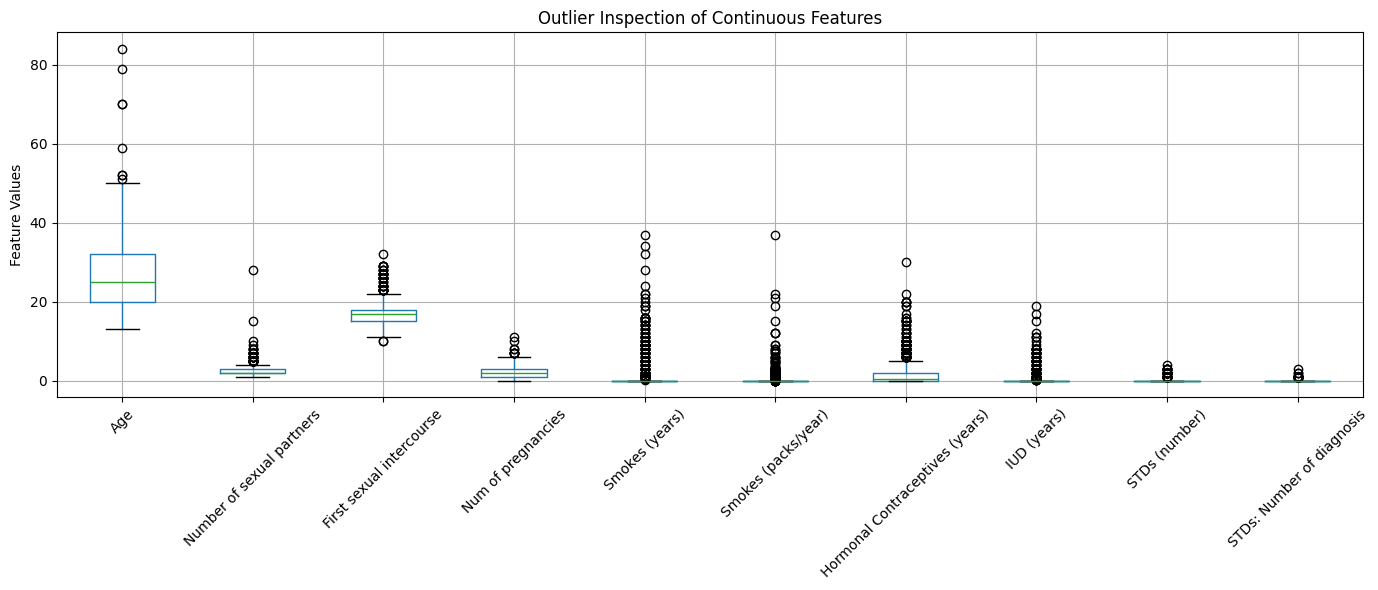

In [18]:
# Outlier Inspection for Continuous Variables


plt.figure(figsize=(14, 6))

# Boxplot across all continuous features
X_cont.boxplot(rot=45)

plt.title("Outlier Inspection of Continuous Features")
plt.ylabel("Feature Values")

plt.tight_layout()
plt.show()


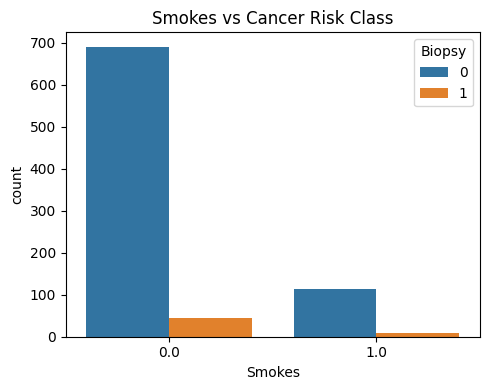

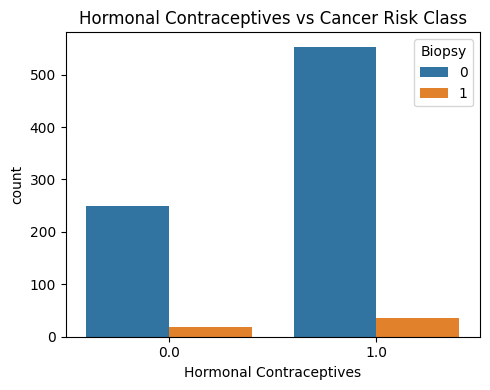

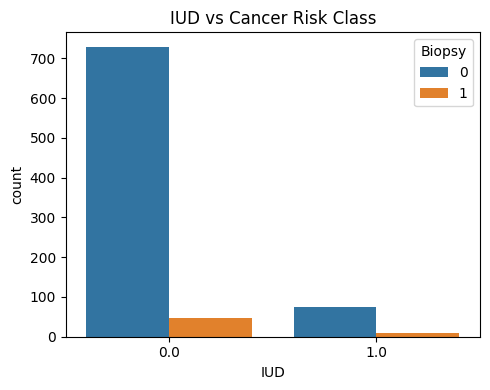

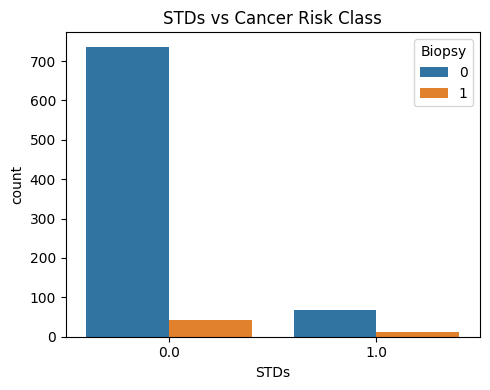

In [19]:
# Binary Features vs Cancer Risk Class


binary_to_plot = ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs']

eda_df_bin = X.copy()
eda_df_bin['Biopsy'] = y.values

for col in binary_to_plot:
    if col in eda_df_bin.columns:
        plt.figure(figsize=(5, 4))
        sns.countplot(x=col, hue='Biopsy', data=eda_df_bin)

        plt.title(f"{col} vs Cancer Risk Class")
        plt.tight_layout()
        plt.show()


In [20]:
# Split data: 70% Train, 15% Validation, 15% Test
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: 50% of temp for validation, 50% for test (15% each of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set:   600 samples (69.9%)
Validation set: 129 samples (15.0%)
Test set:       129 samples (15.0%)


In [21]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training set std:  {X_train_scaled.std():.6f}")

Scaled training set mean: -0.000000
Scaled training set std:  0.937437


In [22]:
# Apply SMOTE to training data only to address class imbalance
# SMOTE generates synthetic minority class samples to balance the dataset
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution before SMOTE:")
print(f"  Negative: {(y_train == 0).sum()}, Positive: {(y_train == 1).sum()}")
print("\nClass distribution after SMOTE:")
print(f"  Negative: {(y_train_smote == 0).sum()}, Positive: {(y_train_smote == 1).sum()}")

Class distribution before SMOTE:
  Negative: 562, Positive: 38

Class distribution after SMOTE:
  Negative: 562, Positive: 562


In [23]:
# Define common training parameters
# Hyperparameters optimized through systematic experimentation
INPUT_DIM = X_train_smote.shape[1]
EPOCHS = 150
BATCH_SIZE = 64  # Optimized: experiments showed batch_size=64 achieved best AUC-ROC (0.94)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Increased patience for better convergence
    restore_best_weights=True,
    verbose=1)

print(f"Input dimensions: {INPUT_DIM}")
print(f"Training samples: {X_train_smote.shape[0]}")

Input dimensions: 33
Training samples: 1124


In [24]:
# Model A: Simple MLP with single hidden layer
# Architecture: Input -> Dense(64, ReLU) -> Output(1, Sigmoid)
# Optimized: 64 neurons, learning_rate=0.001 achieved F1=0.67, Recall=0.75

model_a = Sequential([
    Dense(64, activation='relu',
          input_dim=INPUT_DIM,
          name='hidden_layer'),
    Dense(1, activation='sigmoid',
          name='output_layer')],
                     name='Simple_MLP')

model_a.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

model_a.summary()

Model: "Simple_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train Model A
history_a = model_a.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4711 - loss: 0.7351 - val_accuracy: 0.5969 - val_loss: 0.7329
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7335 - loss: 0.5423 - val_accuracy: 0.8062 - val_loss: 0.5939
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8888 - loss: 0.4217 - val_accuracy: 0.8682 - val_loss: 0.4832
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9283 - loss: 0.3363 - val_accuracy: 0.8992 - val_loss: 0.4051
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9409 - loss: 0.2741 - val_accuracy: 0.9225 - val_loss: 0.3523
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9580 - loss: 0.2284 - val_accuracy: 0.9225 - val_loss: 0.3162
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9613 - loss: 0.1951 - val_accuracy: 0.9225 - val_loss: 0.2918
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9679 - loss: 0.1708 - val_accuracy: 0.9

In [26]:
# Model B: Deeper network with dropout regularization
# Architecture: Input -> Dense(64, ReLU) -> Dropout(0.1) -> Dense(32, ReLU) -> Output(1, Sigmoid)

model_b = Sequential([
    Dense(64, activation='relu', input_dim=INPUT_DIM, name='hidden_1'),
    Dropout(0.1, name='dropout_1'),  # Optimized: Lower dropout rate
    Dense(32, activation='relu', name='hidden_2'),
    Dense(1, activation='sigmoid', name='output_layer')],
                     name='Deep_MLP')

model_b.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

model_b.summary()

Model: "Deep_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train Model B
history_b = model_b.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5069 - loss: 0.7110 - val_accuracy: 0.7519 - val_loss: 0.6701
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8658 - loss: 0.4516 - val_accuracy: 0.9147 - val_loss: 0.4598
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9343 - loss: 0.3122 - val_accuracy: 0.9147 - val_loss: 0.3303
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9428 - loss: 0.2237 - val_accuracy: 0.9225 - val_loss: 0.2686
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9472 - loss: 0.1734 - val_accuracy: 0.9225 - val_loss: 0.2443
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.1399 - val_accuracy: 0.9302 - val_loss: 0.2355
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9638 - loss: 0.1256 - val_accuracy: 0.9302 - val_loss: 0.2278
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9700 - loss: 0.1085 - val_accuracy: 0.9302 -

In [28]:
# Model C Part 1: Autoencoder for unsupervised feature learning
# The autoencoder compresses 33 features to 10 latent dimensions

LATENT_DIM = 10

# Encoder
input_layer = Input(shape=(INPUT_DIM,), name='input')
encoded = Dense(20, activation='relu', name='encoder_h1')(input_layer)
latent = Dense(LATENT_DIM, activation='relu', name='latent')(encoded)

# Decoder
decoded = Dense(20, activation='relu', name='decoder_h1')(latent)
output_layer = Dense(INPUT_DIM, activation='linear', name='output')(decoded)

# Full autoencoder
autoencoder = Model(inputs=input_layer, outputs=output_layer, name='Autoencoder')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Encoder only (for feature extraction)
encoder = Model(inputs=input_layer, outputs=latent, name='Encoder')

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_h1 (Dense)              │ (None, 20)             │           680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_h1 (Dense)              │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 33)             │           693 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,803 (7.04 KB)

 Trainable params: 1,803 (7.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train autoencoder on training data (unsupervised)
ae_early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

autoencoder.fit(
    X_train_smote, X_train_smote,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=150,
    batch_size=BATCH_SIZE,
    callbacks=[ae_early_stopping],
    verbose=1)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.2988 - val_loss: 0.8510
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2023 - val_loss: 0.8205
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1164 - val_loss: 0.7931
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0111 - val_loss: 0.7690
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9029 - val_loss: 0.7463
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8189 - val_loss: 0.7239
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7644 - val_loss: 0.7038
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7233 - val_loss: 0.6851
Epoch 9/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6855 - val_loss: 0.6669
Epoch 10/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6491 - val_loss: 0.6493
Epoch 11/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6134 - val_loss: 0.6325
Epoch 12/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [30]:
# Extract encoded features using the trained encoder
X_train_encoded = encoder.predict(X_train_smote, verbose=0)
X_val_encoded = encoder.predict(X_val_scaled, verbose=0)
X_test_encoded = encoder.predict(X_test_scaled, verbose=0)

print(f"Original feature dimension: {INPUT_DIM}")
print(f"Encoded feature dimension: {X_train_encoded.shape[1]}")

Original feature dimension: 33
Encoded feature dimension: 10


In [31]:
# Model C Part 2: MLP classifier on encoded features
# Using optimized architecture with 64 neurons in hidden layer
model_c = Sequential([
    Dense(64, activation='relu', input_dim=LATENT_DIM, name='hidden_layer'),
    Dense(1, activation='sigmoid', name='output_layer')], name='Autoencoder_MLP')

model_c.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

model_c.summary()

Model: "Autoencoder_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train Model C classifier on encoded features
history_c = model_c.fit(
    X_train_encoded, y_train_smote,
    validation_data=(X_val_encoded, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3459 - loss: 1.0634 - val_accuracy: 0.0853 - val_loss: 1.1285
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4749 - loss: 0.7035 - val_accuracy: 0.6279 - val_loss: 0.7034
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8655 - loss: 0.5190 - val_accuracy: 0.8837 - val_loss: 0.5448
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8688 - loss: 0.4244 - val_accuracy: 0.8992 - val_loss: 0.4541
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8763 - loss: 0.3580 - val_accuracy: 0.8992 - val_loss: 0.3989
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8946 - loss: 0.3071 - val_accuracy: 0.9302 - val_loss: 0.3580
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9088 - loss: 0.2694 - val_accuracy: 0.9380 - val_loss: 0.3286
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9227 - loss: 0.2430 - val_accuracy: 0.9457 -

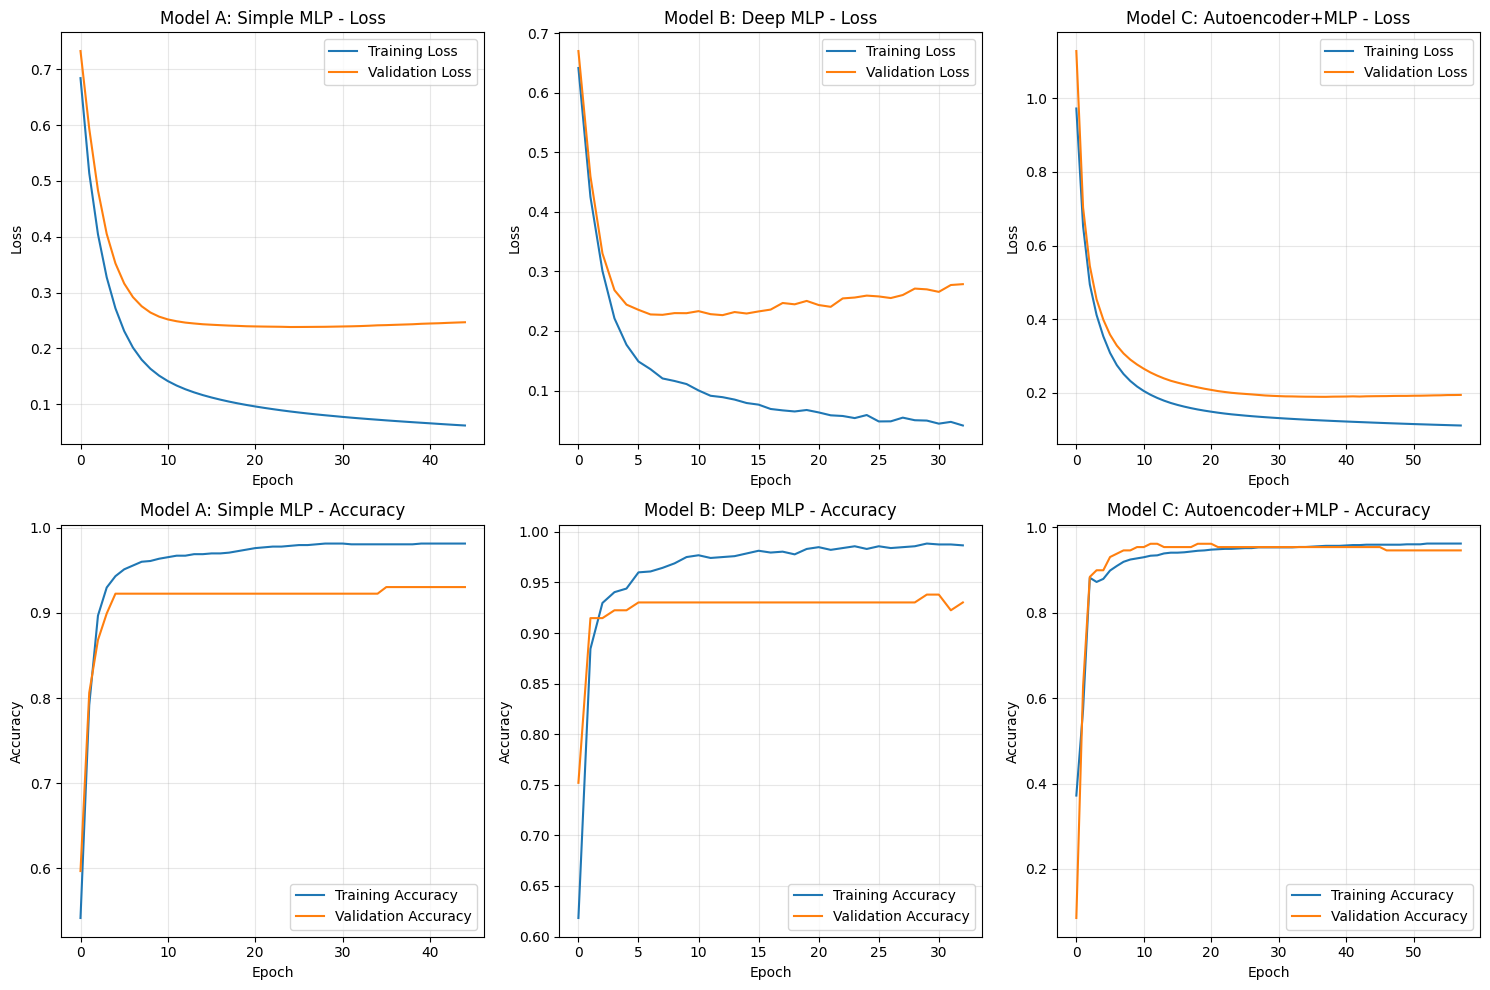

In [33]:
# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

models_info = [
    ('Model A: Simple MLP', history_a),
    ('Model B: Deep MLP', history_b),
    ('Model C: Autoencoder+MLP', history_c)]

for idx, (name, history) in enumerate(models_info):
    # Loss curves
    axes[0, idx].plot(history.history['loss'], label='Training Loss')
    axes[0, idx].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # Accuracy curves
    axes[1, idx].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1, idx].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1, idx].set_title(f'{name} - Accuracy')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return comprehensive metrics."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_prob)}

    return metrics, y_pred, y_pred_prob

In [35]:
# Evaluate all models on test set
metrics_a, y_pred_a, y_prob_a = evaluate_model(model_a, X_test_scaled, y_test, 'Simple MLP')
metrics_b, y_pred_b, y_prob_b = evaluate_model(model_b, X_test_scaled, y_test, 'Deep MLP')
metrics_c, y_pred_c, y_prob_c = evaluate_model(model_c, X_test_encoded, y_test, 'Autoencoder+MLP')

# Create comparison DataFrame
results_df = pd.DataFrame([metrics_a, metrics_b, metrics_c])
results_df = results_df.set_index('Model')

print("Model Performance Comparison on Test Set:")
print("=" * 70)
print(results_df.round(4).to_string())

Model Performance Comparison on Test Set:
                 Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                          
Simple MLP         0.9535     0.6000    0.75    0.6667   0.8874
Deep MLP           0.9535     0.6000    0.75    0.6667   0.8781
Autoencoder+MLP    0.9457     0.5455    0.75    0.6316   0.9101


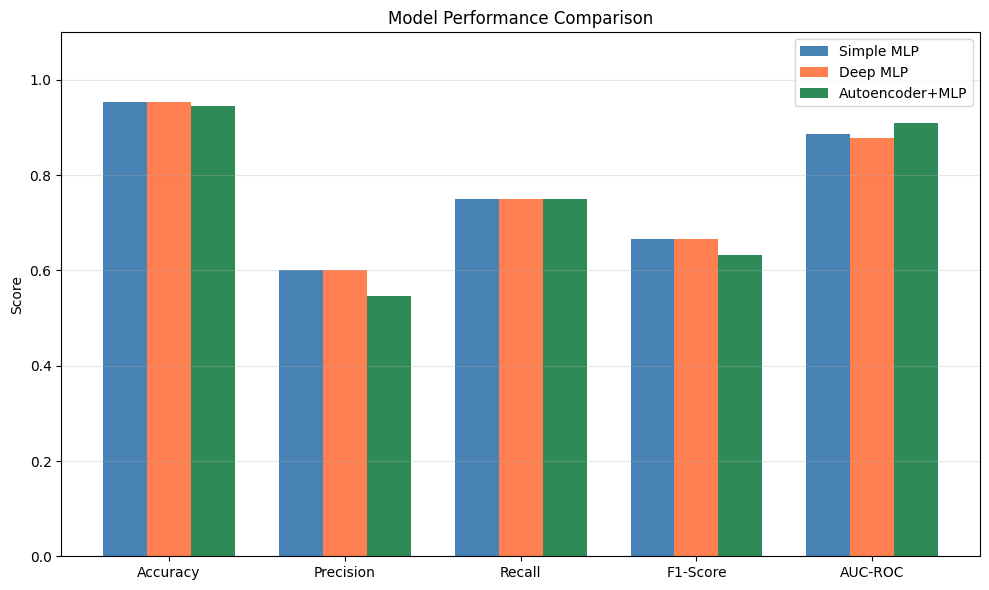

In [36]:
# Visualize performance comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.25

bars1 = ax.bar(x - width, results_df.loc['Simple MLP', metrics_to_plot], width, label='Simple MLP', color='steelblue')
bars2 = ax.bar(x, results_df.loc['Deep MLP', metrics_to_plot], width, label='Deep MLP', color='coral')
bars3 = ax.bar(x + width, results_df.loc['Autoencoder+MLP', metrics_to_plot], width, label='Autoencoder+MLP', color='seagreen')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

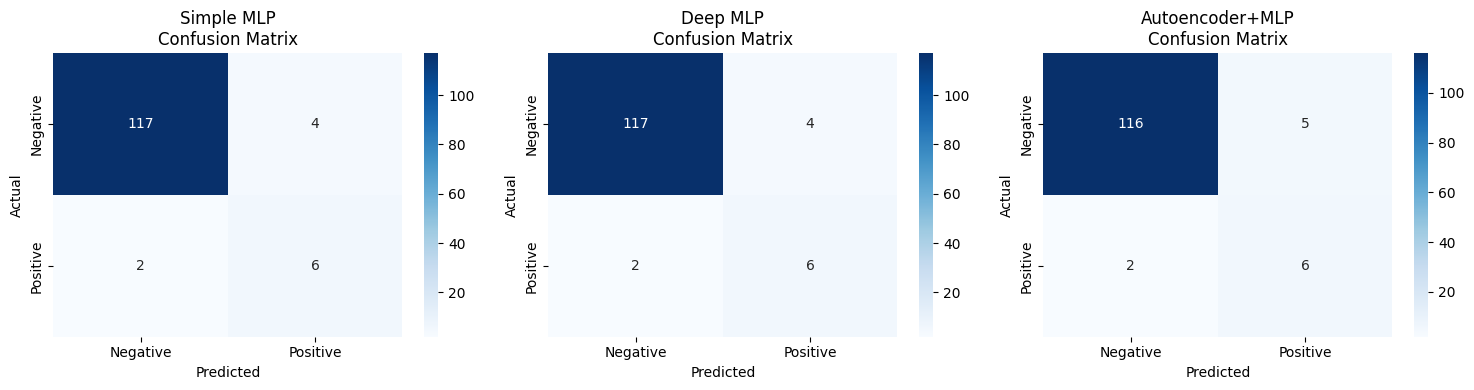

In [37]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = [
    ('Simple MLP', y_pred_a),
    ('Deep MLP', y_pred_b),
    ('Autoencoder+MLP', y_pred_c)]

for idx, (name, y_pred) in enumerate(predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

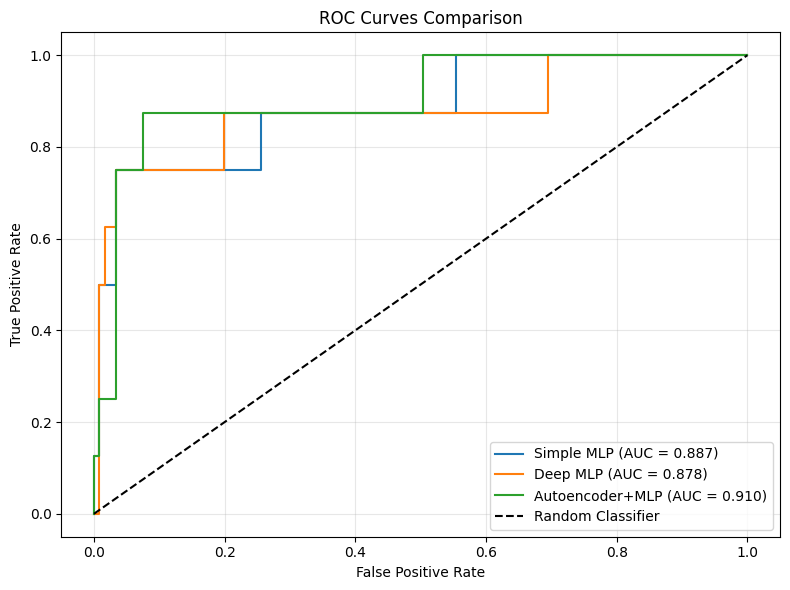

In [38]:
# Plot ROC curves
plt.figure(figsize=(8, 6))

for name, y_prob in [('Simple MLP', y_prob_a), ('Deep MLP', y_prob_b), ('Autoencoder+MLP', y_prob_c)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Detailed classification reports


for name, y_pred in predictions:
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Simple MLP:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       121
    Positive       0.60      0.75      0.67         8

    accuracy                           0.95       129
   macro avg       0.79      0.86      0.82       129
weighted avg       0.96      0.95      0.96       129


Deep MLP:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       121
    Positive       0.60      0.75      0.67         8

    accuracy                           0.95       129
   macro avg       0.79      0.86      0.82       129
weighted avg       0.96      0.95      0.96       129


Autoencoder+MLP:
              precision    recall  f1-score   support

    Negative       0.98      0.96      0.97       121
    Positive       0.55      0.75      0.63         8

    accuracy                           0.95       129
   macro avg       0.76      0.85      0.80       129
weighted avg       0.96      0.9

In [40]:
# Identify best performing model
best_model_idx = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_idx, 'F1-Score']
best_recall = results_df.loc[best_model_idx, 'Recall']


print(f"\nBest Performing Model: {best_model_idx}")
print(f"  - F1-Score: {best_f1:.4f}")
print(f"  - Recall: {best_recall:.4f}")
print("\nFinal Performance Comparison:")
print(results_df.round(4))


Best Performing Model: Simple MLP
  - F1-Score: 0.6667
  - Recall: 0.7500

Final Performance Comparison:
                 Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                          
Simple MLP         0.9535     0.6000    0.75    0.6667   0.8874
Deep MLP           0.9535     0.6000    0.75    0.6667   0.8781
Autoencoder+MLP    0.9457     0.5455    0.75    0.6316   0.9101
